# EDA Techniques | NYC Airbnb Dataset

Exploratory Data Analysis: understanding distributions, summary statistics,
correlations, outlier detection, and initial pattern spotting before modeling.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/AB_NYC_2019.csv')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Summary Statistics

In [2]:
# Numeric columns only
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# Value counts for key categorical columns
print(df['neighbourhood_group'].value_counts())
print()
print(df['room_type'].value_counts())

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


## Distributions

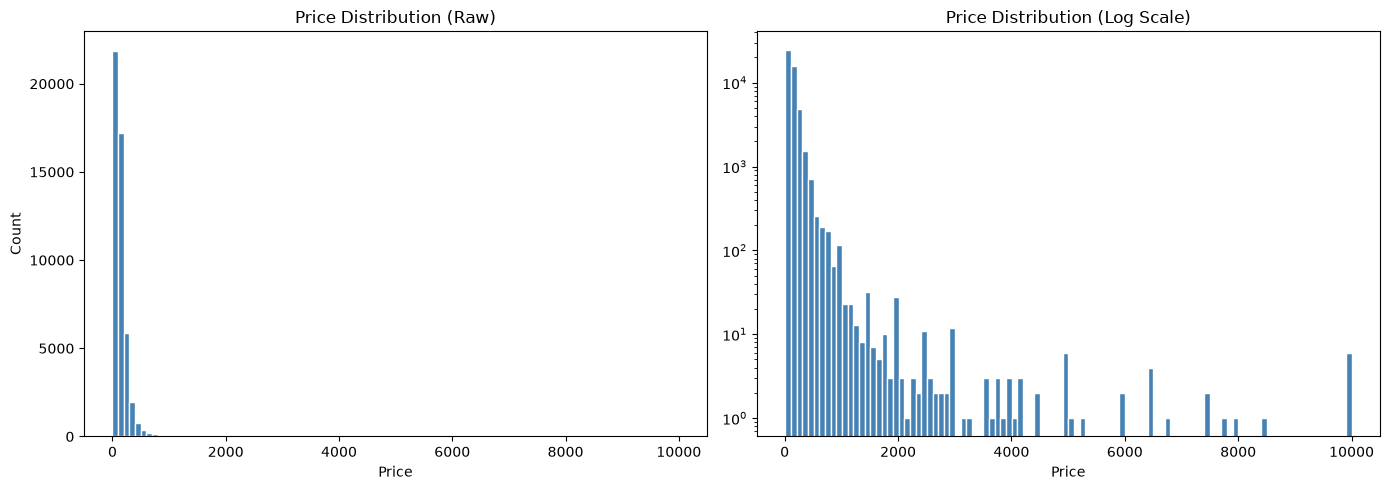

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log-transformed (handles extreme skew)
axes[1].hist(df[df['price'] > 0]['price'], bins=100, 
             color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

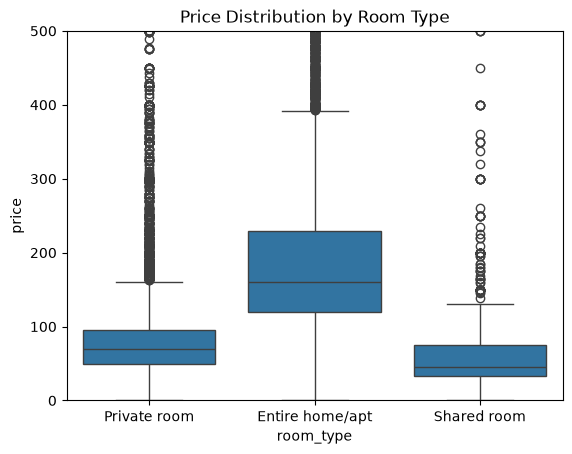

In [5]:
# Distribution across room types
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price Distribution by Room Type')
plt.ylim(0, 500)  # cap y-axis so outliers don't squash the boxes
plt.show()

## Outlier Detection

In [6]:
# How many listings are above $500?
print(f"Listings above $500: {len(df[df['price'] > 500])}")
print(f"Listings above $1000: {len(df[df['price'] > 1000])}")
print(f"Listings at $0: {len(df[df['price'] == 0])}")

# Summary stats just for high-end outliers
df[df['price'] > 1000][['name', 'neighbourhood_group', 
                          'room_type', 'price']].sort_values('price', 
                          ascending=False).head(10)

Listings above $500: 1044
Listings above $1000: 239
Listings at $0: 11


,name,neighbourhood_group,room_type,price
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
45666,Gem of east Flatbush,Brooklyn,Private room,7500


In [7]:
# IQR method for outlier flagging
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"IQR bounds: ${lower:.2f} – ${upper:.2f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

IQR bounds: $-90.00 – $334.00
Outliers detected: 2972 (6.1%)


## Correlation Analysis

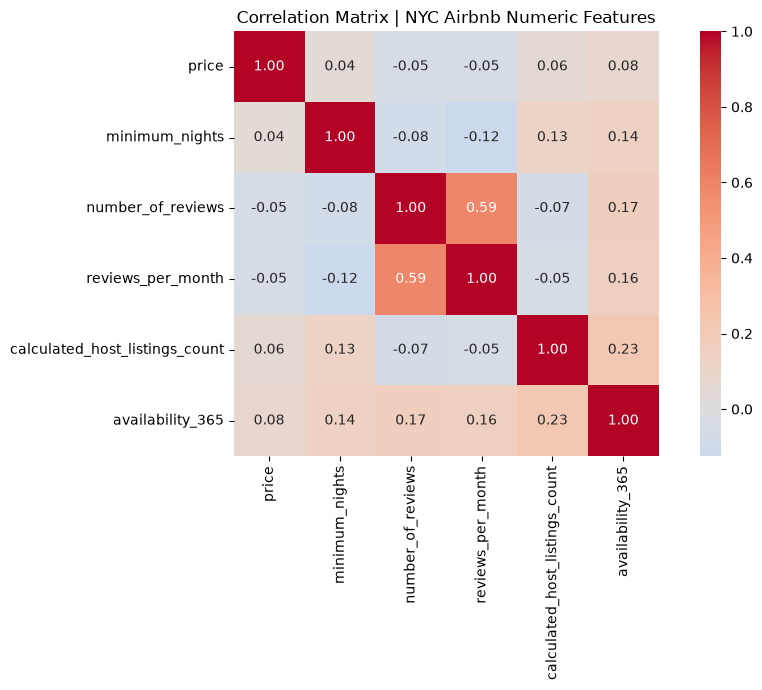

In [ ]:
# Correltation Matrix for Numeric Features
# Select numeric columns only
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 
                'availability_365']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True,       # show correlation values
            fmt='.2f',        # 2 decimal places
            cmap='coolwarm',  # red = positive, blue = negative
            center=0,         # white = no correlation
            square=True)
plt.title('Correlation Matrix | NYC Airbnb Numeric Features')
plt.tight_layout()
plt.show()

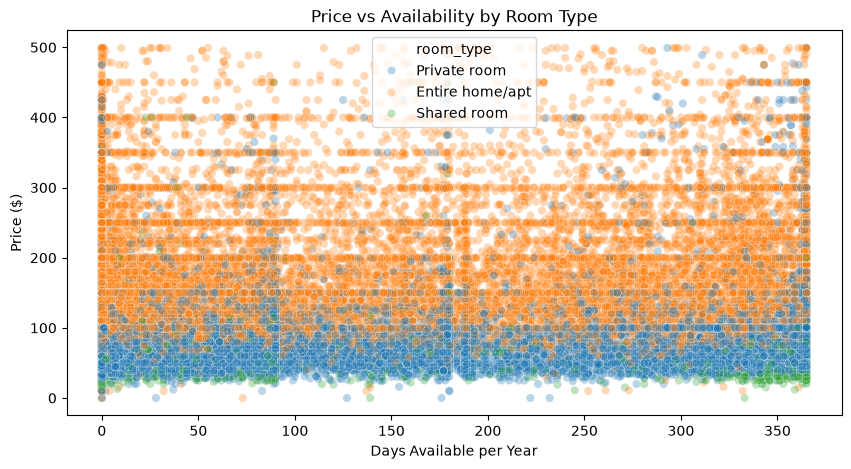

In [ ]:
#Scatter plot: price vs availability
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df[df['price'] < 500],  # filter outliers for readability
                x='availability_365', 
                y='price', 
                hue='room_type', # hue here is 
                alpha=0.3) 
plt.title('Price vs Availability by Room Type')
plt.xlabel('Days Available per Year')
plt.ylabel('Price ($)')
plt.show()

## Summary / Observations

- Price is heavily right-skewed, a log transform is more informative than 
  raw distribution; this will matter in any modeling step.
- Entire home/apt listings show the widest price variance; private and shared 
  rooms are more tightly clustered at lower price points.
- 6.1% of listings (2,972) are statistical outliers by IQR, however these 
  are largely legitimate high-end listings, not data errors. Dropping them 
  purely on statistical grounds would remove real market signal. Decision on 
  handling them will be revisited in notebook 03 (data cleaning).
- Correlation matrix shows weak linear correlations between price and most 
  other numeric features, suggests price is driven more by categorical 
  factors (room type, neighbourhood) than raw numeric ones.
- `minimum_nights` and `availability_365` show near-zero correlation with 
  price — host policy choices don't meaningfully predict price.

**Next**: `03_data_cleaning_feature_engineering.ipynb`, handling outliers 
properly, encoding categoricals, creating new features.